In [1]:
# http://localhost:8888/tree/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import astropy.stats as astro
import scipy
import sys
sys.path.append("../../.'")

from AT_plots import polarPlot_largeDF, cart2pola

In [3]:
anttracks = pd.read_csv("AbbottsWoodsCombinedTidy.csv")

print(anttracks.keys())

/tmp/ipykernel_430276/3518586682.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  anttracks = pd.read_csv("AbbottsWoodsCombinedTidy.csv")


Index(['Date', 'ID', 'frame', 'x', 'y', 'Nest', 'Condition'], dtype='object')


In [4]:
data_path = "/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/"

In [5]:
wigwam = anttracks[anttracks['Nest']=='Wigwam']

print(np.unique(wigwam['Condition']))

['Off-route 1 ZV' 'On-route 1 ZV' 'On-route 2 ZV' 'Unfamiliar FV'
 'Unfamiliar ZV']


In [6]:
"""
def multiCAMplot(cam_samples, test_type:str, model_type:str, w_space = -0.45, h_space=0.1):
    # set the column heading names
    cols = ['Correctly Classified', 'Incorrectly Classified']
    # set the row order
    rows = ["Resolution {}".format(row) for row in ['[452, 144]', '[226, 72]', '[113, 36]', '[57, 18]', '[29, 9]', '[15, 5]', '[8, 3]']]
    # create a blank multiplot with 7 rows and 2 columns. gridspec is used to control spacing
    f, axarr = plt.subplots(7, 2, figsize=(8, 12), gridspec_kw = {'wspace':w_space, 'hspace':h_space}) #, gridspec_kw = {'wspace':0.0005, 'hspace':0.0002}  figsize=(8, 12), gridspec_kw = {'wspace':-0.45, 'hspace':0.1}
    
    def plot_image(ax, img):
        # mini function to plot the images
        ax.imshow(img) 
        ax.grid(False)
        ax.axis('off')
    # loop to plot images in correct row column axis
    for i in range(7):
        for j in range(2):
            plot_image(axarr[i, j], cam_samples[i*2 +j])
    # give the column headings oretty colours
    axarr[0,0].set_title(cols[0], fontsize=10, pad=5, color='#008000')
    axarr[0,1].set_title(cols[1], fontsize=10, pad=5, color= '#CC79A7')
    
    for ax, row in zip(axarr[:,0], rows):
        ax.set_ylabel(row, rotation=0,  ha='right', va='center') # size=10,
    
    plt.suptitle(f"{model_type} {test_type} CAM Images \n Illistrating Areas of Interest \n for Location Classification")
    
    plt.tight_layout()
    plt.savefig(f'CAM_{model_type}_{test_type}.png', dpi=300, bbox_inches='tight')
    plt.show()
"""

'\ndef multiCAMplot(cam_samples, test_type:str, model_type:str, w_space = -0.45, h_space=0.1):\n    # set the column heading names\n    cols = [\'Correctly Classified\', \'Incorrectly Classified\']\n    # set the row order\n    rows = ["Resolution {}".format(row) for row in [\'[452, 144]\', \'[226, 72]\', \'[113, 36]\', \'[57, 18]\', \'[29, 9]\', \'[15, 5]\', \'[8, 3]\']]\n    # create a blank multiplot with 7 rows and 2 columns. gridspec is used to control spacing\n    f, axarr = plt.subplots(7, 2, figsize=(8, 12), gridspec_kw = {\'wspace\':w_space, \'hspace\':h_space}) #, gridspec_kw = {\'wspace\':0.0005, \'hspace\':0.0002}  figsize=(8, 12), gridspec_kw = {\'wspace\':-0.45, \'hspace\':0.1}\n    \n    def plot_image(ax, img):\n        # mini function to plot the images\n        ax.imshow(img) \n        ax.grid(False)\n        ax.axis(\'off\')\n    # loop to plot images in correct row column axis\n    for i in range(7):\n        for j in range(2):\n            plot_image(axarr[i, j], c

In [7]:
def multiTrackplot(df, imagelist, w_space = -0.45, h_space=-0.01): #-0.45, 0.1
    # set the column heading names
    cols = np.unique(df['Nest'])
    #print(cols)
    #plt.imshow(imagelist[-1])
    #plt.show()
    # set the row order
    conditions = np.unique(df['Condition'])
    rows= ["Condition {}".format(cond) for cond in conditions]
    numrows = int(np.ceil(len(rows)/2))
    print(f" number of rows : {numrows}")
    numcols = len(cols)
    print(f" number of cols : {numcols}")
    
    # create a blank multiplot with 7 rows and 2 columns. gridspec is used to control spacing
    f, axarr = plt.subplots(numrows, numcols, figsize=(10, 10), gridspec_kw = {'wspace':w_space, 'hspace':h_space}) #8,12 gridspec_kw = {'wspace':0.0005, 'hspace':0.0002}  figsize=(8, 12), gridspec_kw = {'wspace':-0.45, 'hspace':0.1}
    
    def plot_image(ax, img):
        # mini function to plot the images
        ax.imshow(img) 
        ax.grid(False)
        ax.axis('off')
    # loop to plot images in correct row column axis
    for i in range(numrows):
        for j in range(numcols):
            plot_image(axarr[i, j], imagelist[i*2 +j])
    # give the column headings oretty colours
    axarr[0,0].set_title(cols[0], color='#008000')
    axarr[0,1].set_title(cols[1], color= '#CC79A7')
    
    #for ax, row in zip(axarr[:,0], rows):
    #    ax.set_ylabel(row, rotation=0,  ha='right', va='center') # size=10,
    
    f.suptitle(f"Abbotts Woods Wood Ants \n initial heading (30cm) \n seporated by nest and condition", fontsize=7)
    
    f.tight_layout()
    #plt.savefig(f"{data_path}testingFacetGrid.png", dpi=100, bbox_inches='tight') #Facet_bycondition 300
    plt.show()

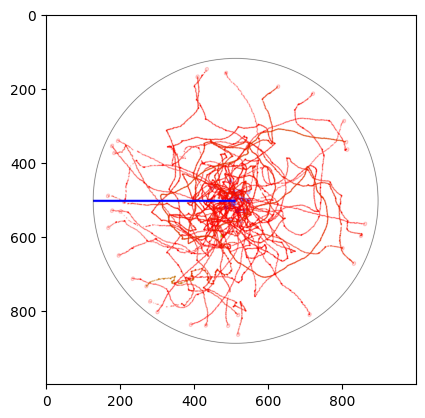

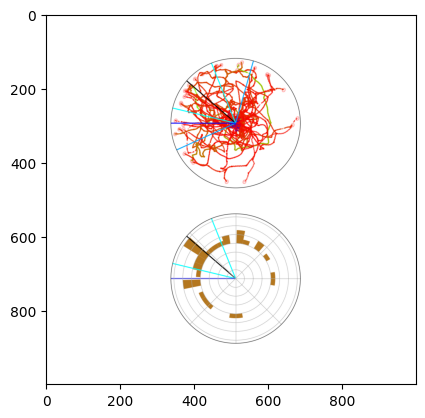

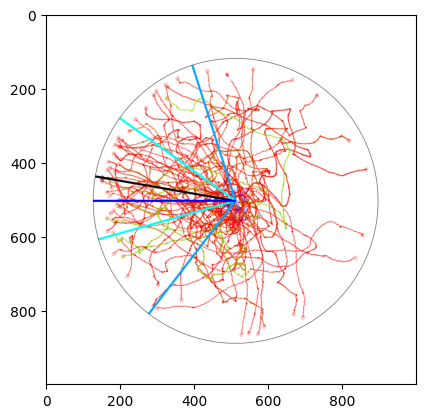

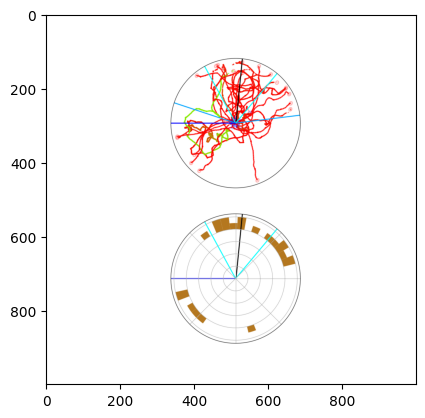

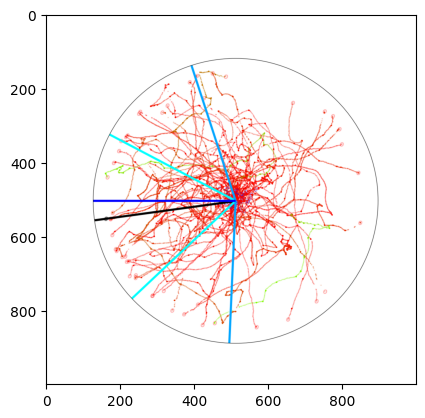

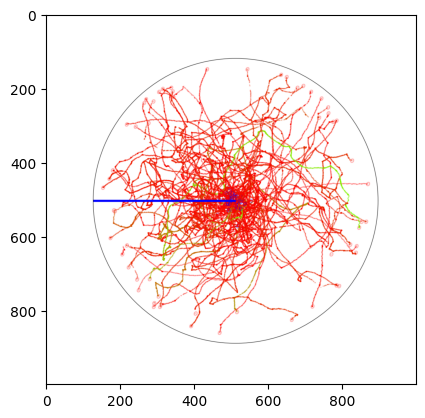

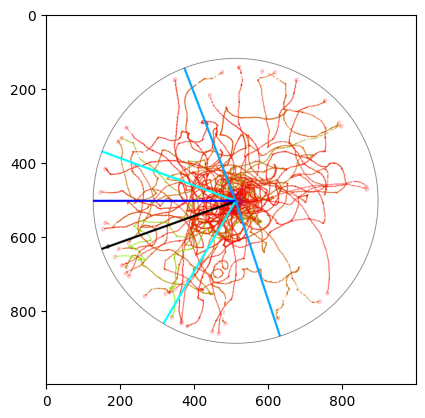

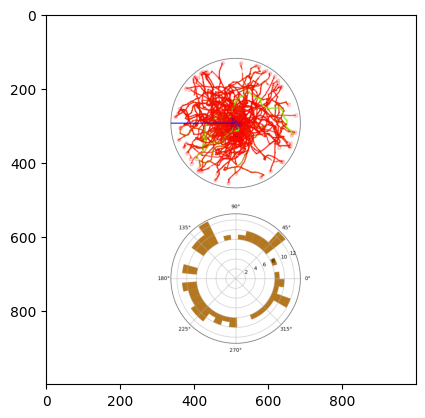

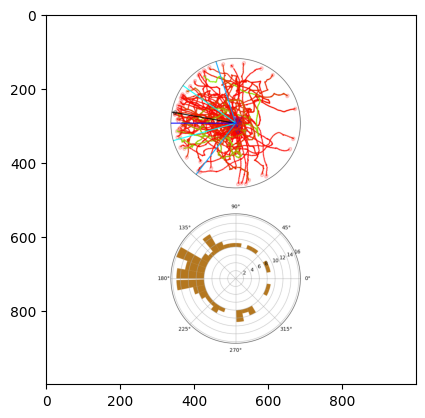

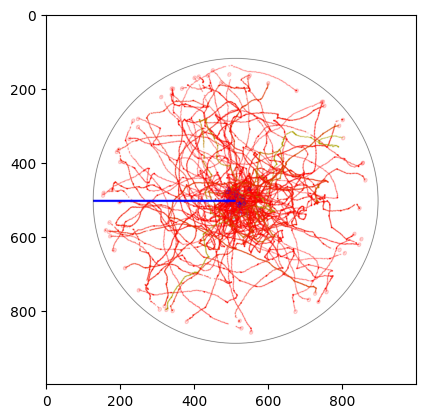

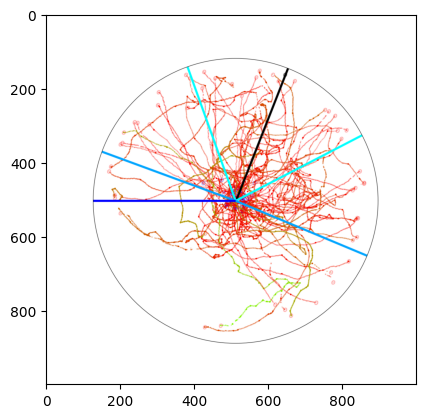

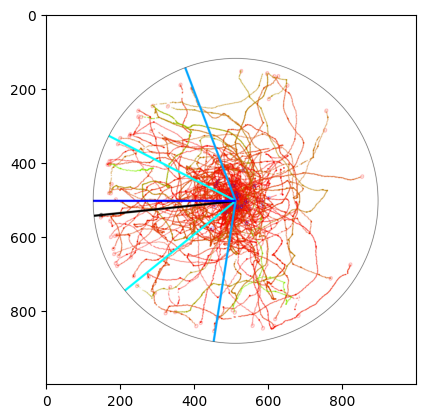

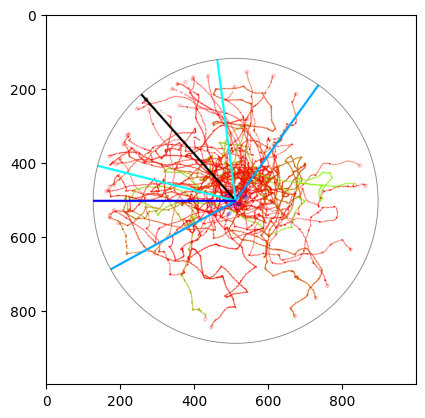

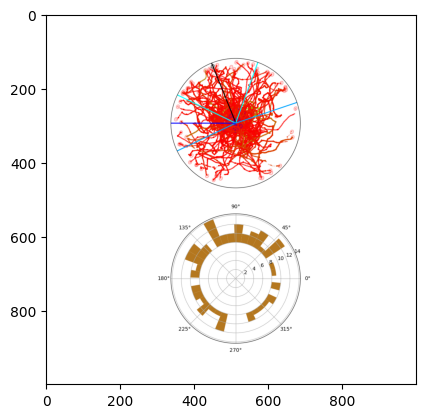

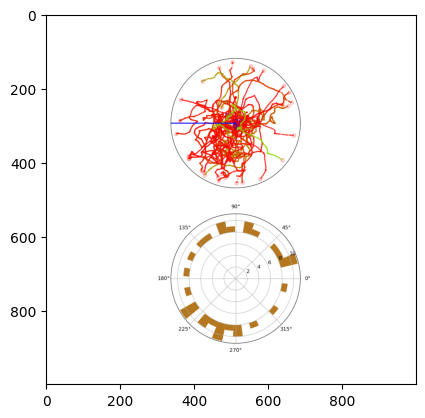

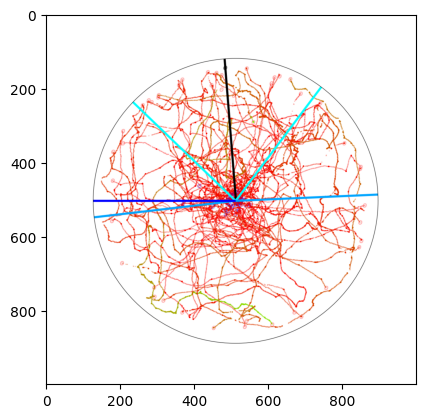

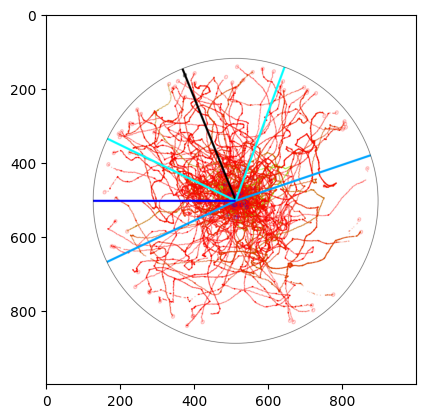

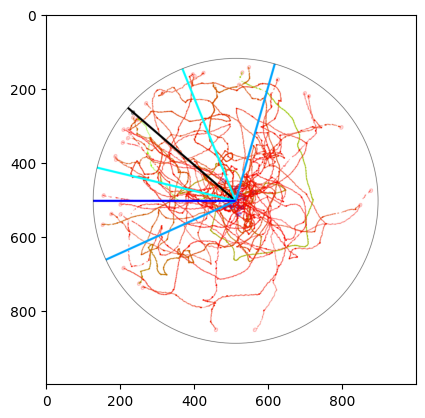

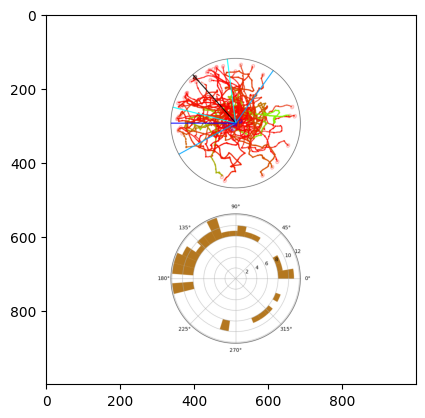

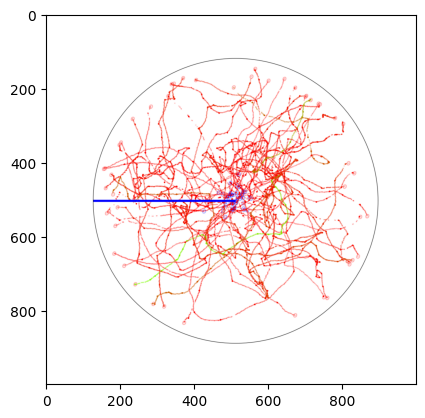

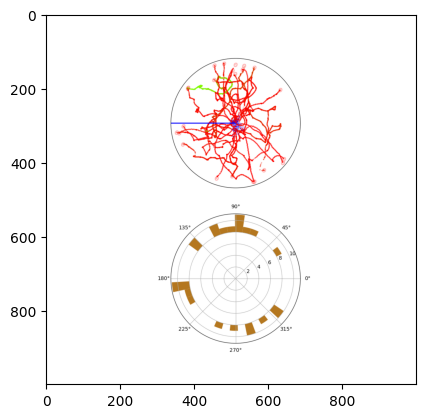

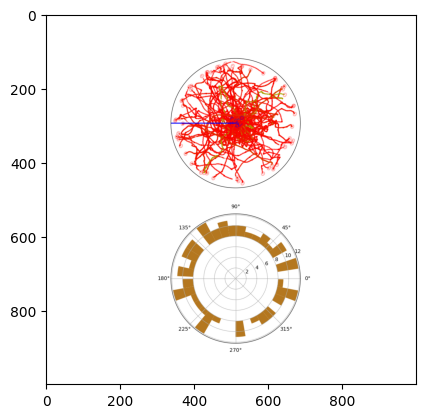

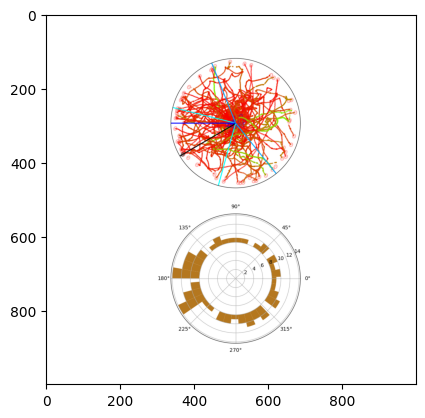

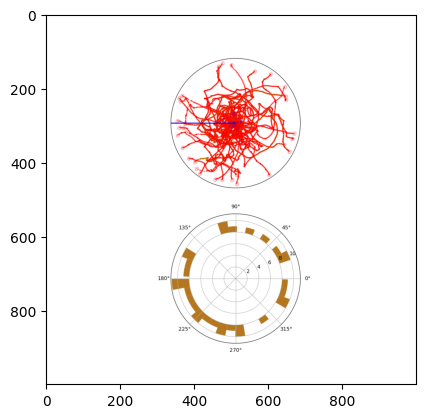

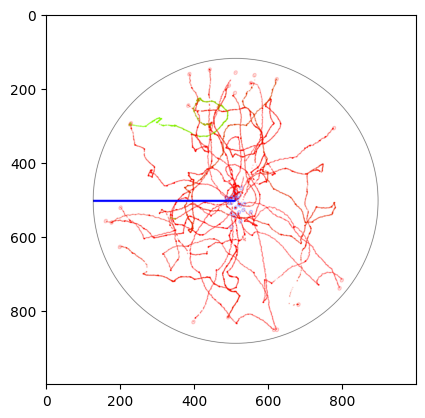

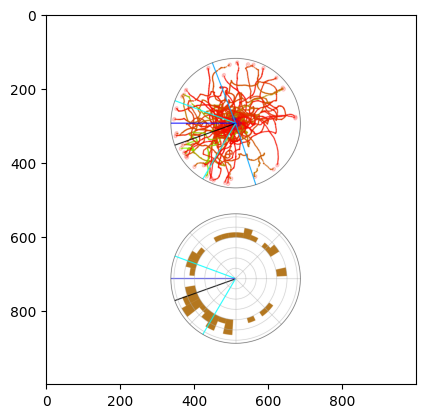

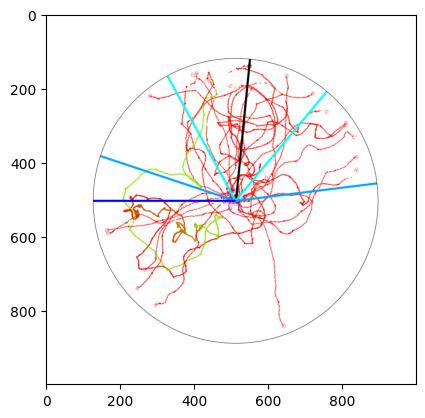

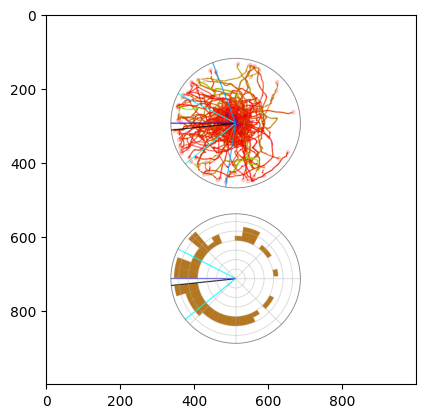

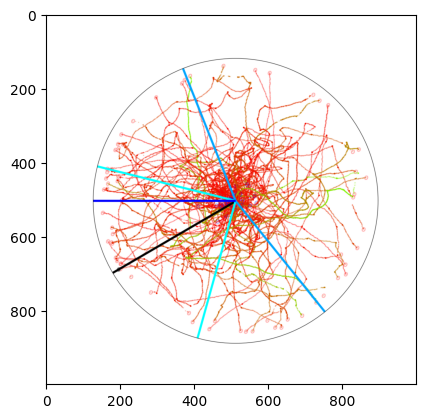

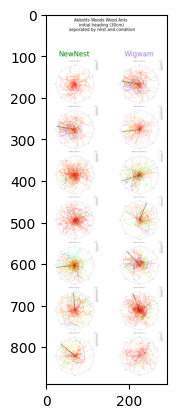

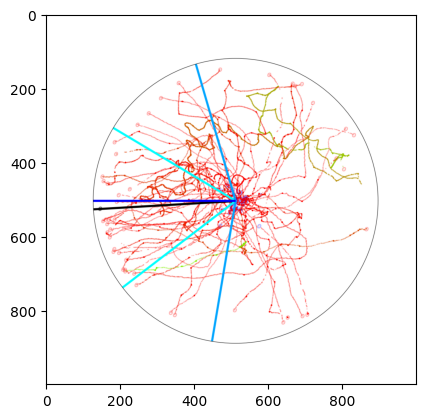

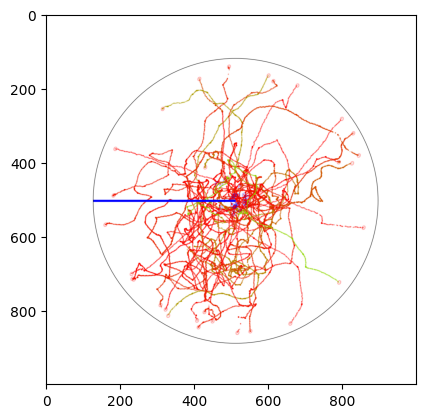

In [8]:
tracks = []

for image in os.listdir(data_path):
    if str(image[-3:]) == "png":
        readim = cv2.imread(data_path+image)
        #cv2.imshow("Image", readim)
        plt.imshow(readim)
        plt.show()
    tracks.append(readim)

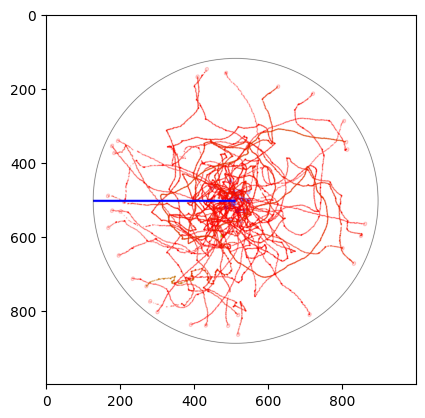

In [9]:
plt.imshow(tracks[0])

In [10]:
print(len(tracks))

37


 number of rows : 7
 number of cols : 2


/tmp/ipykernel_430276/1053469425.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  f.tight_layout()


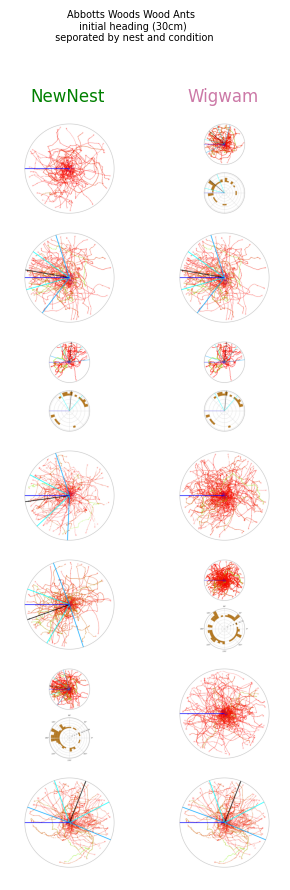

In [11]:
multiTrackplot(anttracks,imagelist=tracks, w_space = -0.75, h_space=-0.06)

In [81]:
def polarPlot_overlayed_largeDF(df, specify=None, nest=None, indivcol = False, save=False, save_path='/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/'):
    # handles the plotting of a large df with multiple seporable vars
    #ids = np.unique(df['ID'])

    print(df)

    if nest is not None:
        df = df[df['Nest']==nest]

    print(df)
            
    if specify is not None:
        df = df[df['Condition']==specify]


    print(df)
    max_len = max(df['frame'])

    df_justfames = df.loc[:, ['ID', 'frame']] 
    #df_justfames['ID'] = df_justfames['ID'].astype("int")
    framelist = df_justfames.groupby(['ID']).max()
    #print(framelist)
    #print(framelist[0][0])
    min_len = framelist.min()
    
    print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
    print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")
    
    # I want the dynamic colour to be related to the condition. so do i need to split the df into condition type. then take the max len.
    conditions = [np.unique(df['Condition'])]
    conditions= conditions[0]
    
    for cond in conditions:
        print(cond)
        df_touse = df[df['Condition']== str(cond)]
        #print(np.unique([type(i) for i in df_touse['ID']]))
        
        max_len = max(df_touse['frame'])
        df_touse['ID'] = df_touse['ID'].astype(str)
        ids = np.unique(df_touse['ID'])
        nestname = ""
        print(str(np.unique(df_touse['Nest'])).lower())
        if str(np.unique(df_touse['Nest'])[0]).lower() == "wigwam":
            nestname = 'N1'
        elif str(np.unique(df_touse['Nest'])[0]).lower() == "newnest":
            nestname = 'N2'
        
    
        #print(ids)
        #for x in ids:    
        #new_df = df_touse[df_touse['ID']== x] # *
        #filename = df_touse['Nest']
        #print("number of frames: ", len(new_df['frame']))
        #if indivcol:
        #    max_len = max(new_df['frame'])
        #print("max frames ", new_df['frame'], new_df['Condition'], x)
        create_Overlayed_polar_plot2(df_touse, max_len, title=f"{nestname} {np.unique(df_touse['Condition'])[0]}", save=save, save_path=save_path) #  {np.unique(df_touse['ID'])} {(max(new_df['frame'])/25)/60:.2f}  {max(new_df['frame'])/25} seconds    = 
        # frames per 25s    =  {int(np.floor(((max(df_touse['frame'])/25)%3600)/60))} : {((max(df_touse['frame'])/25)%3600)%60:.2f}  m:s  \n {max(df_touse['frame'])} 
        

In [220]:

def create_Overlayed_polar_plot2(df_coordinates, max_len, title:str, pindex='frame', save =False, xname='x', yname='y', bkgrnd=None, step =10, foodcentered =False, save_path='/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/'):
    # create plot base
    fig = plt.figure(figsize=(10, 10)) #10, 10
    #ax2 = fig.add_subplot(222,projection='polar')
    ax2 = fig.add_subplot(211, projection='polar')
    ax3 = fig.add_subplot(212, projection='polar')
    alphaval = 0.2

    ids = np.unique(df_coordinates['ID'])
    longestdf = {'id': 0, 'length': 0, 'scat_ele' :0}
    final_heading_list = []
    cart_final_heading_list = []
    max_r = 0
    
    if bkgrnd is not None:
        implot = ax1.imshow(bkgrnd)

    for id in ids:
        newdf = df_coordinates[df_coordinates['ID']== id]
        df_len = len(newdf)
        
        _x = np.array(newdf[xname])
        _y =  np.array(newdf[yname])
        dx_ = newdf[xname].diff(periods=1)
        dy_ = newdf[yname].diff(periods=1)
        
        if foodcentered:
            newx = np.array(newdf['new_x'])
            newy = np.array(newdf['new_y'])
            theta, r = cart2pola(newx, newy)

        theta, r = cart2pola(_x, _y)
        final_heading_list.append(theta[-1])
        
        if r[-1] > max_r:
            max_r = r[-1]
        
        # Plot the points
        scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
        ax2.grid(False)
        
    
        # plot final pos
        ax2.scatter(theta[-1], r[-1], alpha=alphaval, marker='$o$',s= 60, c= 'blue') 
        ax2.scatter(theta[0], r[0], alpha=alphaval, marker='$o$',s= 60, c= 'red') 

        if df_len > longestdf['length']: # ensure that legend is created once
            longestdf['length'] = df_len
            longestdf['scat_ele'] = scatter2.legend_elements()

    #print(f"final headings:  {final_heading_list}")
    histn, histbins = np.histogram(final_heading_list, bins=36)
    histwidths = np.diff(histbins)
    histrad = histn#[rad+2 if rad<=2 else rad for rad in histn]
    #print(f"hist rads {histrad} len{len(histrad)}  minus1 {len(histrad)-1}")
    
    final_heading_array = np.array(final_heading_list)
    rayleigh_ans = astro.rayleightest(final_heading_array) # astro rayleightest wants radians
    final_heading_listdeg = [np.rad2deg(i) for i in final_heading_list]
    #print(f"len histbins {len(histbins)}  len histrad {len(histrad)}   widths {len(histwidths)}")
    ax3.bar(histbins[:-1], histrad, align='edge', width= histwidths, bottom=8)
    if rayleigh_ans <= 0.05:
        mean_heading_theta = scipy.stats.circmean(final_heading_array) # circ mean wants radians
        var_heading_theta = scipy.stats.circvar(final_heading_array)
        std_heading_theta = scipy.stats.circstd(final_heading_array)
        #print(f"mean theta type {type(mean_heading_theta)} mean: {mean_heading_theta}")
        print(f" mean head rad {mean_heading_theta}")
        print(f" std head rad {std_heading_theta}")
        print(f" var head rad {var_heading_theta}")
    
        #ax2.scatter(mean_heading_theta, max_r, alpha=0.4, marker='$o$',s= 60, c= 'k') 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta),  # V
            np.sin(mean_heading_theta),    # U [0]
            ec='k', scale=1)# 
        ax3.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta),  # V
            np.sin(mean_heading_theta),    # U [0]
            ec='k', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta+var_heading_theta),  # V
            np.sin(mean_heading_theta+var_heading_theta),    # U [0]
            color='yellow', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta-var_heading_theta),  # V
            np.sin(mean_heading_theta-var_heading_theta),    # U [0]
            color='yellow', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta+var_heading_theta),  # V
            np.sin(mean_heading_theta+var_heading_theta),    # U [0]
            color='yellow', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta-var_heading_theta),  # V
            np.sin(mean_heading_theta-var_heading_theta),    # U [0]
            color='yellow', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta+std_heading_theta),  # V
            np.sin(mean_heading_theta+std_heading_theta),    # U [0]
            color='orange', scale=1)# 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta-std_heading_theta),  # V
            np.sin(mean_heading_theta-std_heading_theta),    # U [0]
            color='orange', scale=1)# 
    ax2.quiver(0,  # x mean_heading_theta
        0,      # y max_r
        np.cos(np.deg2rad(180)),  # V
        np.sin(np.deg2rad(180)),    # U [0]
        color='red', scale=1)# 
    ax3.quiver(0,  # x mean_heading_theta
        0,      # y max_r
        np.cos(np.deg2rad(180)),  # V
        np.sin(np.deg2rad(180)),    # U [0]
        color='red', scale=1)# 
    ax2.set_yticklabels([])
    ax2.set_xticklabels([])
    ax3.set_yticklabels([])
    ax3.set_xticklabels([])
    #legend2 = fig.legend(*longestdf['scat_ele'],
    #            loc="upper right", title="frames")
    #fig.add_artist(legend2)
    #fig.suptitle(title, y=1)
    plt.tight_layout()
    #fig.axes(False)

    if save == True:
        #cv2.imwrite(f"{save_path}{title}_hist.jpg", fig)
        plt.savefig(fname=save_path+title+"_hist"+".png", format='png')
        #cv2.imsave()
    
    plt.show()

           Date   ID  frame           x           y     Nest  \
0        Jul-18  286      0    9.996429   15.959446   Wigwam   
1        Jul-18  286      1   10.018027   15.991669   Wigwam   
2        Jul-18  286      2    9.978276   15.939924   Wigwam   
3        Jul-18  286      3    9.837419   16.045487   Wigwam   
4        Jul-18  286      4    9.832482   16.051758   Wigwam   
...         ...  ...    ...         ...         ...      ...   
2681831  Sep-26  286    833  238.362807  163.557813  NewNest   
2681832  Sep-26  286    834  239.051067  164.125071  NewNest   
2681833  Sep-26  286    835  239.074259  164.616213  NewNest   
2681834  Sep-26  286    836  239.180470  164.978996  NewNest   
2681835  Sep-26  286    837  240.005126  165.190812  NewNest   

                     Condition  
0                On-route 1 ZV  
1                On-route 1 ZV  
2                On-route 1 ZV  
3                On-route 1 ZV  
4                On-route 1 ZV  
...                        ...  


/tmp/ipykernel_430276/2350347857.py:26: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_430276/2350347857.py:27: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")
/tmp/ipykernel_430276/993536743.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped 

['newnest']
 mean head rad 3.4841771593781403
 std head rad 1.545195251800671
 var head rad 0.6969368814418673


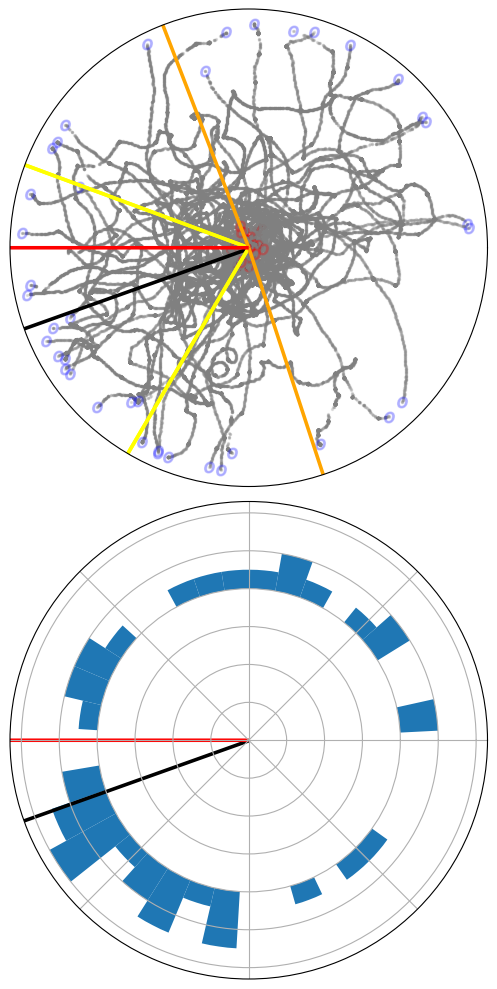

In [221]:
polarPlot_overlayed_largeDF(anttracks, specify ='Eye-capped off-route 1',  nest='NewNest', indivcol=True, save=False)

 two cols
n1 and n1

each subplot holds two figs. top is the ant tracks, bottom is the circ hist



In [88]:
newnamepath = "/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/newnames/"

In [222]:
wig = anttracks[anttracks['Nest']=='Wigwam']

print(wig)

          Date   ID  frame          x           y    Nest      Condition
0       Jul-18  286      0   9.996429   15.959446  Wigwam  On-route 1 ZV
1       Jul-18  286      1  10.018027   15.991669  Wigwam  On-route 1 ZV
2       Jul-18  286      2   9.978276   15.939924  Wigwam  On-route 1 ZV
3       Jul-18  286      3   9.837419   16.045487  Wigwam  On-route 1 ZV
4       Jul-18  286      4   9.832482   16.051758  Wigwam  On-route 1 ZV
...        ...  ...    ...        ...         ...     ...            ...
456678  Aug-16  521  13179  39.245423  175.292429  Wigwam  Unfamiliar ZV
456679  Aug-16  521  13180  39.267156  175.344488  Wigwam  Unfamiliar ZV
456680  Aug-16  521  13181  39.259052  175.367538  Wigwam  Unfamiliar ZV
456681  Aug-16  521  13182  39.207780  175.381939  Wigwam  Unfamiliar ZV
456682  Aug-16  521  13183  39.218738  175.360241  Wigwam  Unfamiliar ZV

[456683 rows x 7 columns]


In [90]:
nests

array(['NewNest', 'Wigwam'], dtype=object)

In [223]:
#conds = np.unique(anttracks['Condition'])
nests = np.unique(anttracks['Nest'])

n1 = anttracks[anttracks['Nest']=='Wigwam']#np.unique(anttracks[anttracks['Nest']=='Wigwam'])
conds = np.unique(n1['Condition'])

           Date   ID  frame           x           y     Nest  \
0        Jul-18  286      0    9.996429   15.959446   Wigwam   
1        Jul-18  286      1   10.018027   15.991669   Wigwam   
2        Jul-18  286      2    9.978276   15.939924   Wigwam   
3        Jul-18  286      3    9.837419   16.045487   Wigwam   
4        Jul-18  286      4    9.832482   16.051758   Wigwam   
...         ...  ...    ...         ...         ...      ...   
2681831  Sep-26  286    833  238.362807  163.557813  NewNest   
2681832  Sep-26  286    834  239.051067  164.125071  NewNest   
2681833  Sep-26  286    835  239.074259  164.616213  NewNest   
2681834  Sep-26  286    836  239.180470  164.978996  NewNest   
2681835  Sep-26  286    837  240.005126  165.190812  NewNest   

                     Condition  
0                On-route 1 ZV  
1                On-route 1 ZV  
2                On-route 1 ZV  
3                On-route 1 ZV  
4                On-route 1 ZV  
...                        ...  


/tmp/ipykernel_430276/2350347857.py:26: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_430276/2350347857.py:27: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")
/tmp/ipykernel_430276/993536743.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped 

 mean head rad 3.277099795554471
 std head rad 1.3910734332638197
 var head rad 0.6199842760743968


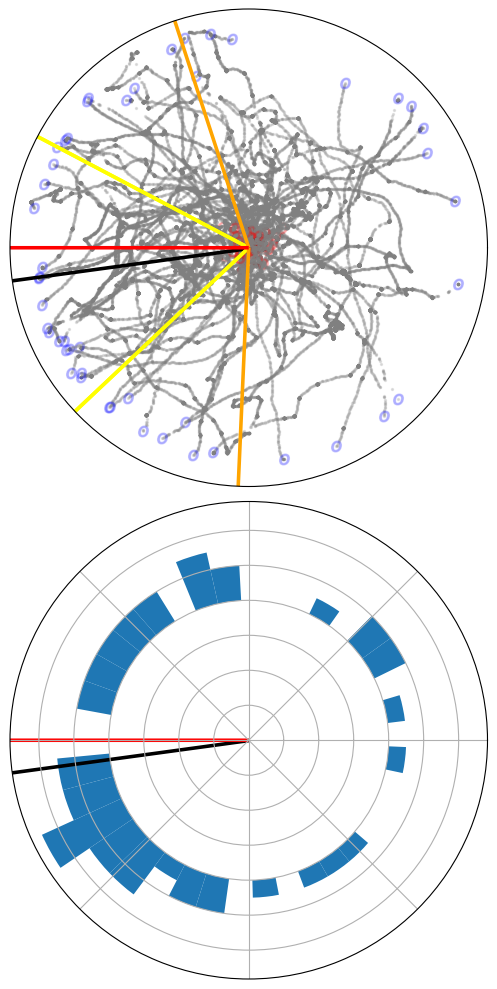

           Date   ID  frame           x           y     Nest  \
0        Jul-18  286      0    9.996429   15.959446   Wigwam   
1        Jul-18  286      1   10.018027   15.991669   Wigwam   
2        Jul-18  286      2    9.978276   15.939924   Wigwam   
3        Jul-18  286      3    9.837419   16.045487   Wigwam   
4        Jul-18  286      4    9.832482   16.051758   Wigwam   
...         ...  ...    ...         ...         ...      ...   
2681831  Sep-26  286    833  238.362807  163.557813  NewNest   
2681832  Sep-26  286    834  239.051067  164.125071  NewNest   
2681833  Sep-26  286    835  239.074259  164.616213  NewNest   
2681834  Sep-26  286    836  239.180470  164.978996  NewNest   
2681835  Sep-26  286    837  240.005126  165.190812  NewNest   

                     Condition  
0                On-route 1 ZV  
1                On-route 1 ZV  
2                On-route 1 ZV  
3                On-route 1 ZV  
4                On-route 1 ZV  
...                        ...  


/tmp/ipykernel_430276/2350347857.py:26: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_430276/2350347857.py:27: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")
/tmp/ipykernel_430276/993536743.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped 

 mean head rad 3.1998305922579475
 std head rad 1.346066223531637
 var head rad 0.5958410909259327


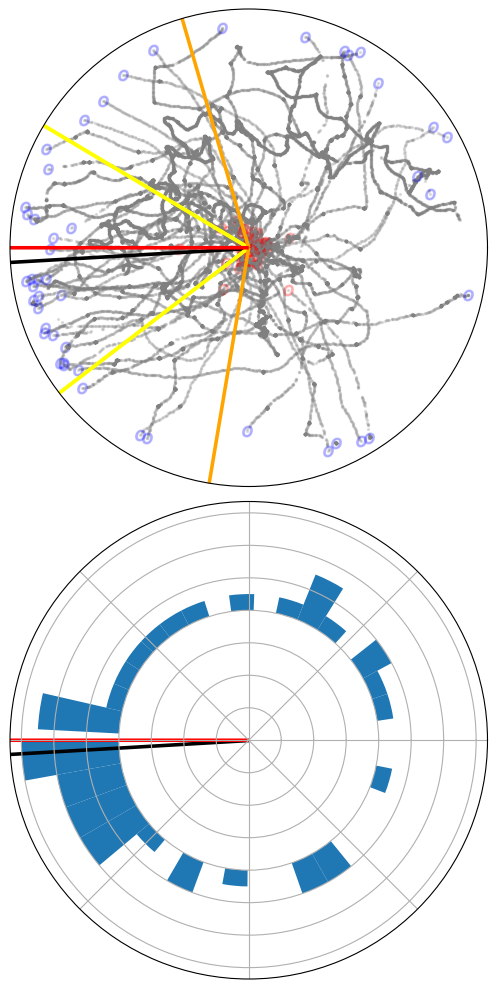

           Date   ID  frame           x           y     Nest  \
0        Jul-18  286      0    9.996429   15.959446   Wigwam   
1        Jul-18  286      1   10.018027   15.991669   Wigwam   
2        Jul-18  286      2    9.978276   15.939924   Wigwam   
3        Jul-18  286      3    9.837419   16.045487   Wigwam   
4        Jul-18  286      4    9.832482   16.051758   Wigwam   
...         ...  ...    ...         ...         ...      ...   
2681831  Sep-26  286    833  238.362807  163.557813  NewNest   
2681832  Sep-26  286    834  239.051067  164.125071  NewNest   
2681833  Sep-26  286    835  239.074259  164.616213  NewNest   
2681834  Sep-26  286    836  239.180470  164.978996  NewNest   
2681835  Sep-26  286    837  240.005126  165.190812  NewNest   

                     Condition  
0                On-route 1 ZV  
1                On-route 1 ZV  
2                On-route 1 ZV  
3                On-route 1 ZV  
4                On-route 1 ZV  
...                        ...  


/tmp/ipykernel_430276/2350347857.py:26: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_430276/2350347857.py:27: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")
/tmp/ipykernel_430276/993536743.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped 

 mean head rad 1.1968813529368278
 std head rad 1.5923161940383588
 var head rad 0.7185316949736744


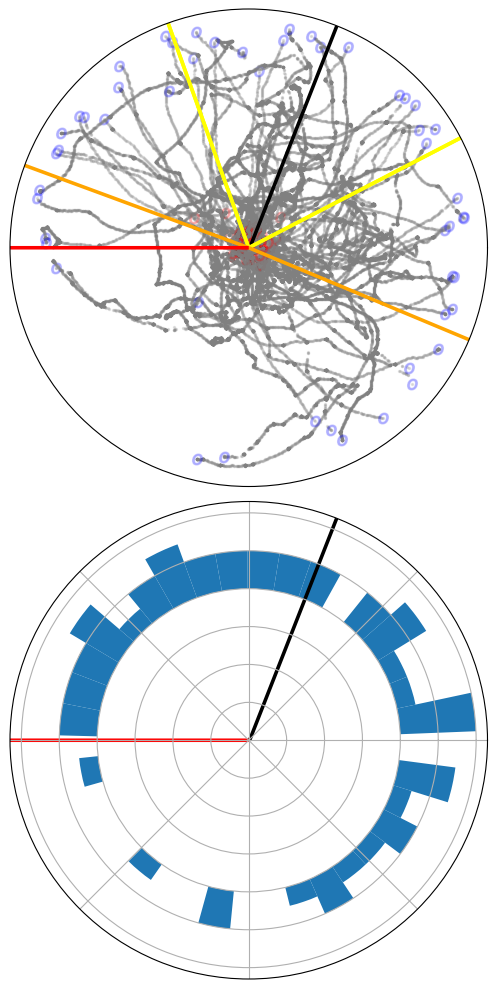

           Date   ID  frame           x           y     Nest  \
0        Jul-18  286      0    9.996429   15.959446   Wigwam   
1        Jul-18  286      1   10.018027   15.991669   Wigwam   
2        Jul-18  286      2    9.978276   15.939924   Wigwam   
3        Jul-18  286      3    9.837419   16.045487   Wigwam   
4        Jul-18  286      4    9.832482   16.051758   Wigwam   
...         ...  ...    ...         ...         ...      ...   
2681831  Sep-26  286    833  238.362807  163.557813  NewNest   
2681832  Sep-26  286    834  239.051067  164.125071  NewNest   
2681833  Sep-26  286    835  239.074259  164.616213  NewNest   
2681834  Sep-26  286    836  239.180470  164.978996  NewNest   
2681835  Sep-26  286    837  240.005126  165.190812  NewNest   

                     Condition  
0                On-route 1 ZV  
1                On-route 1 ZV  
2                On-route 1 ZV  
3                On-route 1 ZV  
4                On-route 1 ZV  
...                        ...  


/tmp/ipykernel_430276/2350347857.py:26: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_430276/2350347857.py:27: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")
/tmp/ipykernel_430276/993536743.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped 

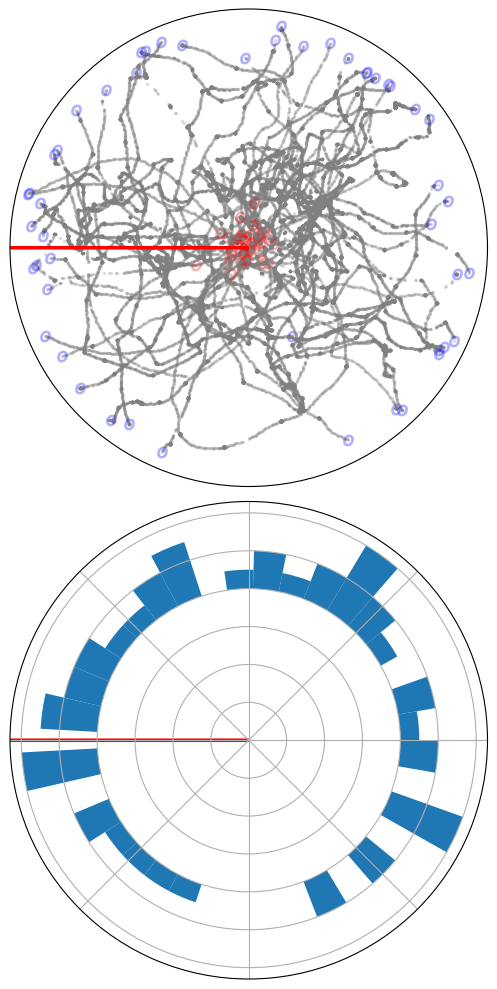

           Date   ID  frame           x           y     Nest  \
0        Jul-18  286      0    9.996429   15.959446   Wigwam   
1        Jul-18  286      1   10.018027   15.991669   Wigwam   
2        Jul-18  286      2    9.978276   15.939924   Wigwam   
3        Jul-18  286      3    9.837419   16.045487   Wigwam   
4        Jul-18  286      4    9.832482   16.051758   Wigwam   
...         ...  ...    ...         ...         ...      ...   
2681831  Sep-26  286    833  238.362807  163.557813  NewNest   
2681832  Sep-26  286    834  239.051067  164.125071  NewNest   
2681833  Sep-26  286    835  239.074259  164.616213  NewNest   
2681834  Sep-26  286    836  239.180470  164.978996  NewNest   
2681835  Sep-26  286    837  240.005126  165.190812  NewNest   

                     Condition  
0                On-route 1 ZV  
1                On-route 1 ZV  
2                On-route 1 ZV  
3                On-route 1 ZV  
4                On-route 1 ZV  
...                        ...  


/tmp/ipykernel_430276/2350347857.py:26: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_430276/2350347857.py:27: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")
/tmp/ipykernel_430276/993536743.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped 

 mean head rad 1.6507214808638273
 std head rad 1.6066635615749656
 var head rad 0.7249174102515163


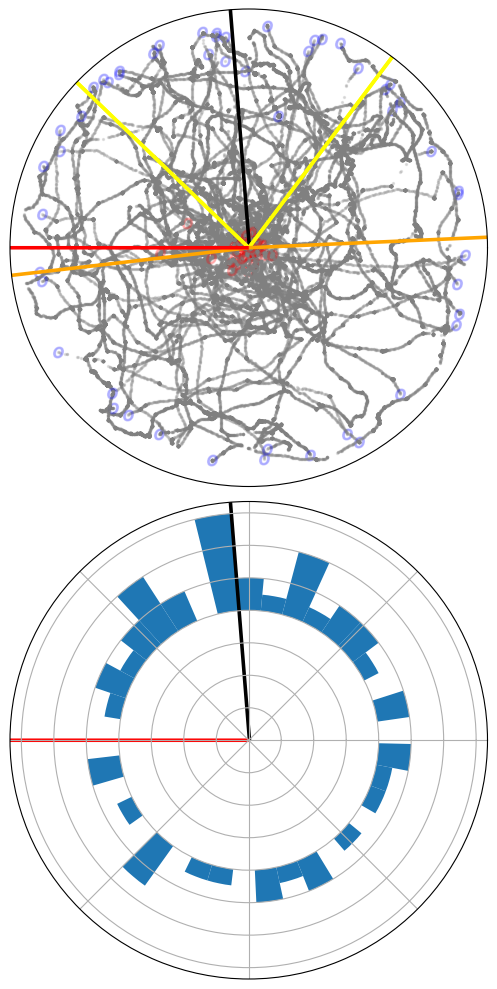

In [224]:
for nest in nests:
    if nest == 'Wigwam':
        for cond in conds:
            polarPlot_overlayed_largeDF(anttracks, specify =cond,  nest=nest, indivcol=True, save=True, save_path= newnamepath)

           Date   ID  frame           x           y     Nest  \
0        Jul-18  286      0    9.996429   15.959446   Wigwam   
1        Jul-18  286      1   10.018027   15.991669   Wigwam   
2        Jul-18  286      2    9.978276   15.939924   Wigwam   
3        Jul-18  286      3    9.837419   16.045487   Wigwam   
4        Jul-18  286      4    9.832482   16.051758   Wigwam   
...         ...  ...    ...         ...         ...      ...   
2681831  Sep-26  286    833  238.362807  163.557813  NewNest   
2681832  Sep-26  286    834  239.051067  164.125071  NewNest   
2681833  Sep-26  286    835  239.074259  164.616213  NewNest   
2681834  Sep-26  286    836  239.180470  164.978996  NewNest   
2681835  Sep-26  286    837  240.005126  165.190812  NewNest   

                     Condition  
0                On-route 1 ZV  
1                On-route 1 ZV  
2                On-route 1 ZV  
3                On-route 1 ZV  
4                On-route 1 ZV  
...                        ...  


/tmp/ipykernel_430276/2350347857.py:26: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_430276/2350347857.py:27: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


['newnest']


/tmp/ipykernel_430276/993536743.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


 mean head rad 3.245009571729025
 std head rad 1.31249371093189
 var head rad 0.5773960684568725


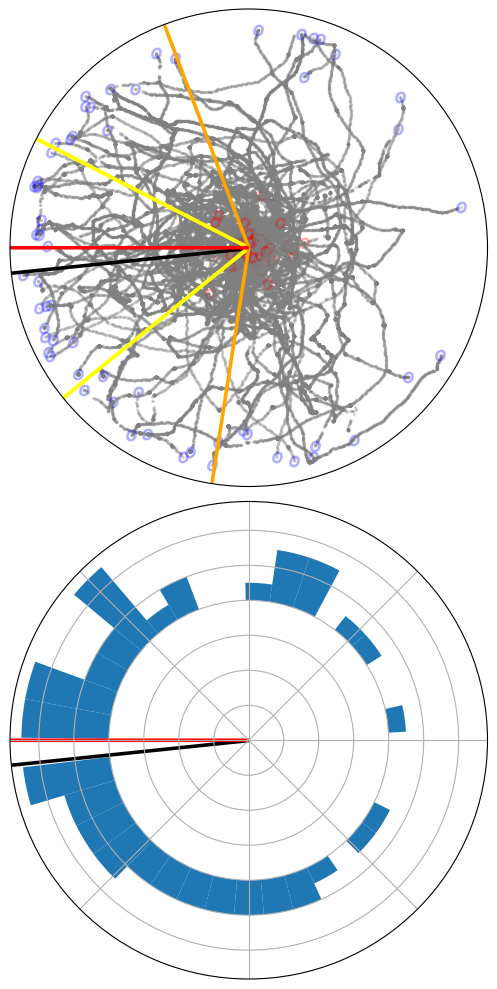

           Date   ID  frame           x           y     Nest  \
0        Jul-18  286      0    9.996429   15.959446   Wigwam   
1        Jul-18  286      1   10.018027   15.991669   Wigwam   
2        Jul-18  286      2    9.978276   15.939924   Wigwam   
3        Jul-18  286      3    9.837419   16.045487   Wigwam   
4        Jul-18  286      4    9.832482   16.051758   Wigwam   
...         ...  ...    ...         ...         ...      ...   
2681831  Sep-26  286    833  238.362807  163.557813  NewNest   
2681832  Sep-26  286    834  239.051067  164.125071  NewNest   
2681833  Sep-26  286    835  239.074259  164.616213  NewNest   
2681834  Sep-26  286    836  239.180470  164.978996  NewNest   
2681835  Sep-26  286    837  240.005126  165.190812  NewNest   

                     Condition  
0                On-route 1 ZV  
1                On-route 1 ZV  
2                On-route 1 ZV  
3                On-route 1 ZV  
4                On-route 1 ZV  
...                        ...  


/tmp/ipykernel_430276/2350347857.py:26: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_430276/2350347857.py:27: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


['newnest']


/tmp/ipykernel_430276/993536743.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


 mean head rad 3.6694501532952133
 std head rad 1.720252712976681
 var head rad 0.7722791399802209


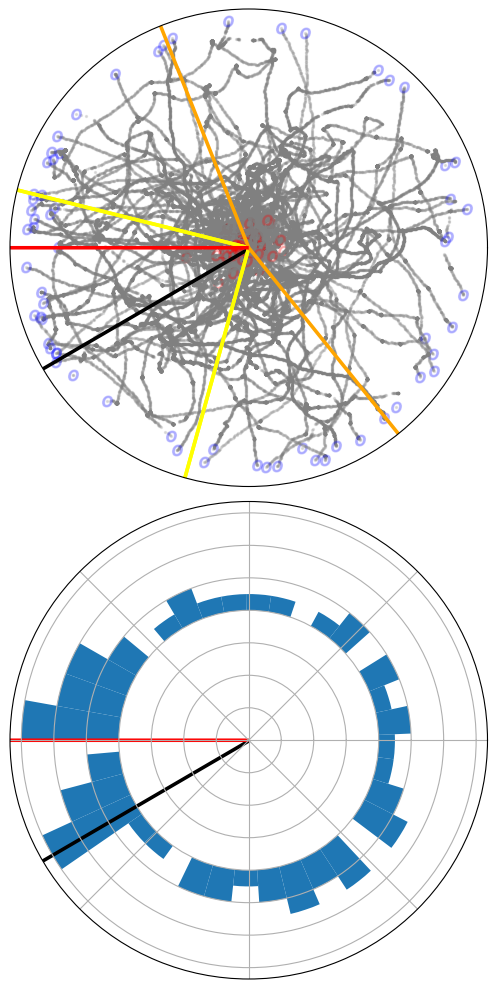

           Date   ID  frame           x           y     Nest  \
0        Jul-18  286      0    9.996429   15.959446   Wigwam   
1        Jul-18  286      1   10.018027   15.991669   Wigwam   
2        Jul-18  286      2    9.978276   15.939924   Wigwam   
3        Jul-18  286      3    9.837419   16.045487   Wigwam   
4        Jul-18  286      4    9.832482   16.051758   Wigwam   
...         ...  ...    ...         ...         ...      ...   
2681831  Sep-26  286    833  238.362807  163.557813  NewNest   
2681832  Sep-26  286    834  239.051067  164.125071  NewNest   
2681833  Sep-26  286    835  239.074259  164.616213  NewNest   
2681834  Sep-26  286    836  239.180470  164.978996  NewNest   
2681835  Sep-26  286    837  240.005126  165.190812  NewNest   

                     Condition  
0                On-route 1 ZV  
1                On-route 1 ZV  
2                On-route 1 ZV  
3                On-route 1 ZV  
4                On-route 1 ZV  
...                        ...  


/tmp/ipykernel_430276/2350347857.py:26: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_430276/2350347857.py:27: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


['newnest']


/tmp/ipykernel_430276/993536743.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


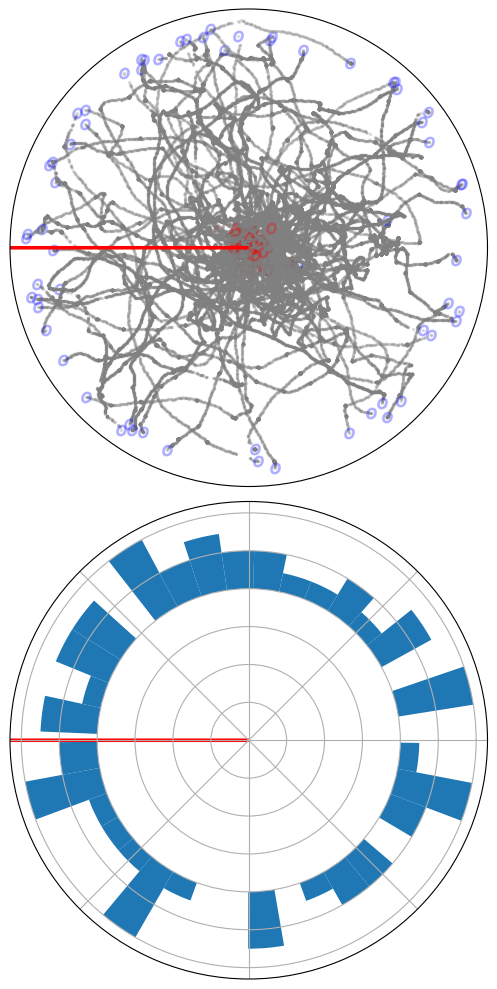

           Date   ID  frame           x           y     Nest  \
0        Jul-18  286      0    9.996429   15.959446   Wigwam   
1        Jul-18  286      1   10.018027   15.991669   Wigwam   
2        Jul-18  286      2    9.978276   15.939924   Wigwam   
3        Jul-18  286      3    9.837419   16.045487   Wigwam   
4        Jul-18  286      4    9.832482   16.051758   Wigwam   
...         ...  ...    ...         ...         ...      ...   
2681831  Sep-26  286    833  238.362807  163.557813  NewNest   
2681832  Sep-26  286    834  239.051067  164.125071  NewNest   
2681833  Sep-26  286    835  239.074259  164.616213  NewNest   
2681834  Sep-26  286    836  239.180470  164.978996  NewNest   
2681835  Sep-26  286    837  240.005126  165.190812  NewNest   

                     Condition  
0                On-route 1 ZV  
1                On-route 1 ZV  
2                On-route 1 ZV  
3                On-route 1 ZV  
4                On-route 1 ZV  
...                        ...  


/tmp/ipykernel_430276/2350347857.py:26: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_430276/2350347857.py:27: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Unfamiliar FV
['newnest']


/tmp/ipykernel_430276/993536743.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


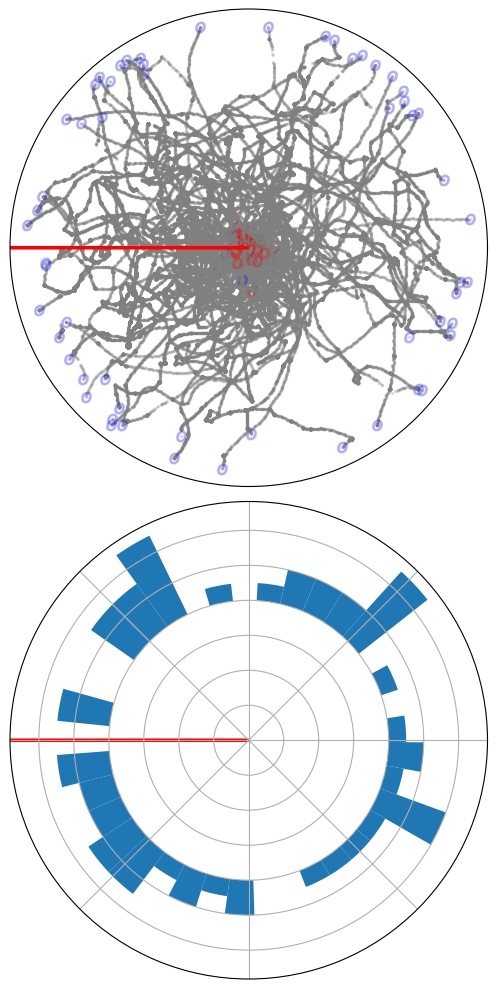

           Date   ID  frame           x           y     Nest  \
0        Jul-18  286      0    9.996429   15.959446   Wigwam   
1        Jul-18  286      1   10.018027   15.991669   Wigwam   
2        Jul-18  286      2    9.978276   15.939924   Wigwam   
3        Jul-18  286      3    9.837419   16.045487   Wigwam   
4        Jul-18  286      4    9.832482   16.051758   Wigwam   
...         ...  ...    ...         ...         ...      ...   
2681831  Sep-26  286    833  238.362807  163.557813  NewNest   
2681832  Sep-26  286    834  239.051067  164.125071  NewNest   
2681833  Sep-26  286    835  239.074259  164.616213  NewNest   
2681834  Sep-26  286    836  239.180470  164.978996  NewNest   
2681835  Sep-26  286    837  240.005126  165.190812  NewNest   

                     Condition  
0                On-route 1 ZV  
1                On-route 1 ZV  
2                On-route 1 ZV  
3                On-route 1 ZV  
4                On-route 1 ZV  
...                        ...  


/tmp/ipykernel_430276/2350347857.py:26: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)} frames    Slowest Ant: {int(max_len)} frames")
/tmp/ipykernel_430276/2350347857.py:27: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"Fastest Ant: {int(min_len)/25} seconds    Slowest Ant: {int(max_len)/25} seconds")


Unfamiliar ZV
['newnest']


/tmp/ipykernel_430276/993536743.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2, vmin=0, vmax=max_len, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


 mean head rad 1.9553081695008536
 std head rad 1.62974186542012
 var head rad 0.7350010125513026


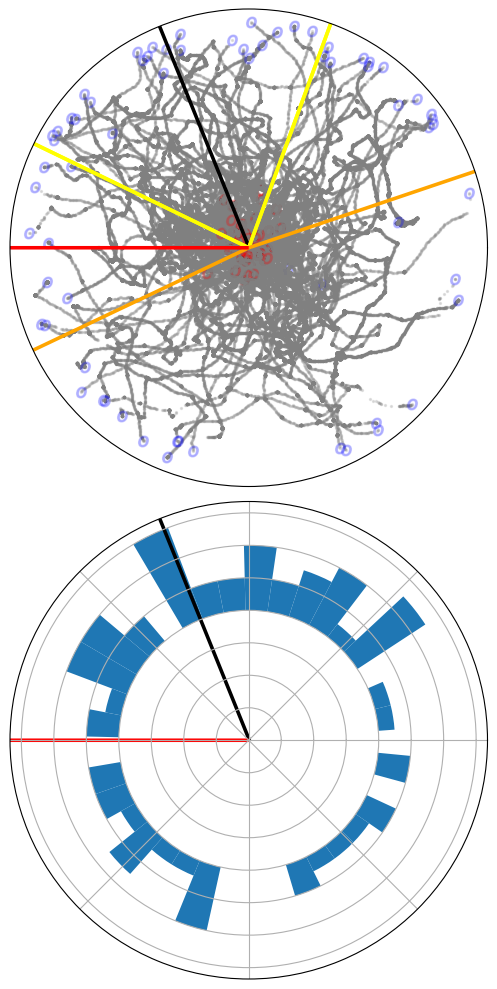

In [225]:
for nest in nests:
    if nest == 'NewNest':
        for cond in conds:
            polarPlot_overlayed_largeDF(anttracks, specify =cond,  nest=nest, indivcol=True, save=True, save_path= newnamepath)

In [ ]:
def multiTrackplot2(df, imagelist, w_space = -0.45, h_space=-0.01): #-0.45, 0.1
    # set the column heading names
    cols = np.unique(df['Nest'])
    #print(cols)
    #plt.imshow(imagelist[-1])
    #plt.show()
    # set the row order
    conditions = np.unique(df['Condition'])
    rows= ["Condition {}".format(cond) for cond in conditions]
    numrows = int(np.ceil(len(rows)/2))
    print(f" number of rows : {numrows}")
    numcols = len(cols)
    print(f" number of cols : {numcols}")
    
    # create a blank multiplot with 7 rows and 2 columns. gridspec is used to control spacing
    f, axarr = plt.subplots(numrows, numcols, figsize=(10, 10), gridspec_kw = {'wspace':w_space, 'hspace':h_space}) #8,12 gridspec_kw = {'wspace':0.0005, 'hspace':0.0002}  figsize=(8, 12), gridspec_kw = {'wspace':-0.45, 'hspace':0.1}
    
    def plot_image(ax, img):
        # mini function to plot the images
        ax.imshow(img) 
        ax.grid(False)
        ax.axis('off')
    # loop to plot images in correct row column axis
    for i in range(numrows):
        for j in range(numcols):
            plot_image(axarr[i, j], imagelist[i*2 +j])
    # give the column headings oretty colours
    axarr[0,0].set_title(cols[0], color='#008000')
    axarr[0,1].set_title(cols[1], color= '#CC79A7')
    
    #for ax, row in zip(axarr[:,0], rows):
    #    ax.set_ylabel(row, rotation=0,  ha='right', va='center') # size=10,
    
    f.suptitle(f"Abbotts Woods Wood Ants \n initial heading (30cm) \n seporated by nest and condition", fontsize=7)
    
    f.tight_layout()
    #plt.savefig(f"{data_path}testingFacetGrid.png", dpi=100, bbox_inches='tight') #Facet_bycondition 300
    plt.show()

# big facet

In [156]:
conditions = np.unique(wigwam['Condition'])

print(conditions)
conditions = [conditions[1], conditions[0], conditions[2], conditions[3], conditions[4]]

print(conditions)

['Off-route 1 ZV' 'On-route 1 ZV' 'On-route 2 ZV' 'Unfamiliar FV'
 'Unfamiliar ZV']
['On-route 1 ZV', 'Off-route 1 ZV', 'On-route 2 ZV', 'Unfamiliar FV', 'Unfamiliar ZV']


In [173]:
filepath = "/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/newnames/"
imagelist = []
for file in os.listdir(filepath):
    #print(file)
    if file[-3:] == 'png':
        f = cv2.imread(filepath+file)
        imagelist.append(file)


print(len(imagelist))
#print(imagelist)

n1s = []
n2s = []

for img in imagelist:
    if 'N2' in img[:5]:
        n2s.append(img)
    elif 'N1' in img[:5]:
        n1s.append(img)

for i in range(len(n2s)):
    print(i, n2s[i])
#print(n2s)
n1s = [n1s[3], n1s[2], n1s[4], n1s[0], n1s[1]]
n2s = [n2s[10], n2s[2], n2s[8], n2s[6], n2s[5]]
#imagelist = []

newimlist = [n1s[0], n2s[0], n1s[1], n2s[1], n1s[2], n2s[2], n1s[3], n2s[3], n1s[4], n2s[4]]

print(newimlist)

18
0 N2 Eye-capped on-route 1_hist.png
1 N2 On-route 1B ZV_hist.png
2 N2 Off-route 1 ZV_hist.png
3 N2 Unfamiliar ZV 3_hist.png
4 N2 Unfamiliar ZV 2_hist.png
5 N2 Unfamiliar FV_hist.png
6 N2 Unfamiliar ZV_hist.png
7 N2 Plus 3m ZV_hist.png
8 N2 On-route 2 ZV_hist.png
9 N2 Eye-capped off-route 1_hist.png
10 N2 On-route 1 ZV_hist.png
11 N2 Route 0m ZV_hist.png
12 N2 Minus 3m ZV_hist.png
['N1 On-route 1 ZV_hist.png', 'N2 On-route 1 ZV_hist.png', 'N1 Off-route 1 ZV_hist.png', 'N2 Off-route 1 ZV_hist.png', 'N1 On-route 2 ZV_hist.png', 'N2 On-route 2 ZV_hist.png', 'N1 Unfamiliar ZV_hist.png', 'N2 Unfamiliar ZV_hist.png', 'N1 Unfamiliar FV_hist.png', 'N2 Unfamiliar FV_hist.png']


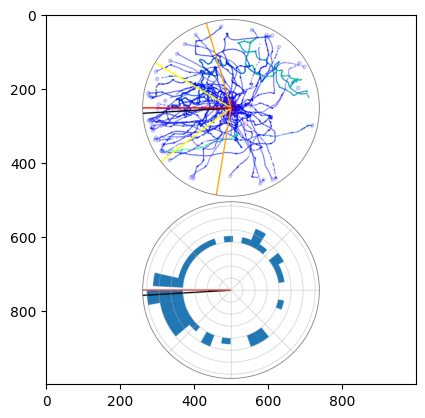

In [215]:
i = cv2.imread(filepath+newimlist[0])
i = cv2.cvtColor(i, cv2.COLOR_BGR2RGB)
plt.imshow(i)
plt.show()

In [1]:
def multiTrackplot2(imagelist, conditions:list,filepath,  w_space = -0.45, h_space=-0.01): #-0.45, 0.1
    # set the column heading names
    print("num conditions : ",len(np.unique(conditions)))
    #cols = np.unique(df['Nest'])
    #cols = 2
    #print(cols)
    #plt.imshow(imagelist[-1])
    #plt.show()
    # set the row order
    #conditions = np.unique(df['Condition'])
    #rows= ["Condition {}".format(cond) for cond in conditions]
    numrows = len(conditions) # int(np.ceil(len(rows)/2))
    print(f" number of rows : {numrows}")
    numcols = 2#len(cols)
    print(f" number of cols : {numcols}")
    
    # create a blank multiplot with 7 rows and 2 columns. gridspec is used to control spacing
    f, axarr = plt.subplots(numrows, numcols, figsize=(10, 10), gridspec_kw = {'wspace':w_space, 'hspace':h_space}, projection='polar') #8,12 gridspec_kw = {'wspace':0.0005, 'hspace':0.0002}  figsize=(8, 12), gridspec_kw = {'wspace':-0.45, 'hspace':0.1}
    
    def plot_image(ax, img):
        # mini function to plot the images
        print(type(img), img)
        img = cv2.imread(filepath+img)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img) 
        ax.grid(False)
        ax.axis('off')
    # loop to plot images in correct row column axis
    for i in range(numrows):
        for j in range(numcols):
            plot_image(axarr[i, j], imagelist[i*2 +j])
    # give the column headings oretty colours
    axarr[0,0].set_title("Nest 1", color='#008000')
    axarr[0,1].set_title("Nest 2", color= '#CC79A7')
    for i in range(len(conditions)):
        axarr[i][0].set_ylabel(conditions[i])
    
    #for ax, row in zip(axarr[:,0], rows):
    #    ax.set_ylabel(row, rotation=0,  ha='right', va='center') # size=10,
    
    f.suptitle(f"Abbotts Woods Wood Ants \n initial heading (30cm) \n seporated by nest and condition", fontsize=10,  y=0.96)
    #plt.subplots_adjust(left=0.25)
    f.tight_layout()
    #plt.savefig(f"{data_path}testingFacetGrid.png", dpi=100, bbox_inches='tight') #Facet_bycondition 300
    plt.show()

In [2]:
multiTrackplot2(newimlist, conditions, filepath, w_space=-0.8, h_space =0.1)

NameError: name 'newimlist' is not defined